In [1]:
# CellCharter Niches

In [2]:
# %% Libraries
import os
import squidpy as sq
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
#import novae
import matplotlib.pyplot as plt
import rapids_singlecell as rsc

import os
#import plotnine as p9

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'refined-manual-niches'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'

# %% Load the object
comb = sc.read_h5ad(CUR_OBJ_PATH)


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import cellcharter as cc

In [4]:
sq.gr.spatial_neighbors_delaunay(
    comb, 
    library_key='sample_name',
    spatial_key='X_spatial', 
    percentile=99
)

INFO     Creating graph using `None` transform and `12` libraries.                                                 


In [5]:
cc.gr.aggregate_neighbors(
    comb, 
    n_layers=3, 
    use_rep='X_resolvi', 
    out_key='X_cellcharter', 
    sample_key='sample_name'
)

100%|██████████| 12/12 [00:22<00:00,  1.88s/it]


In [6]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

In [7]:
model_params = {
    "random_state": 42,
    "trainer_params": {
        "accelerator": "gpu",
        "enable_progress_bar": False,
    },
}

autok = cc.tl.ClusterAutoK(
    n_clusters=(2, 10),
    model_params=model_params,
    max_runs=10,
)

In [8]:
autok.fit(comb, use_rep='X_cellcharter')

Iteration 1/10


  0%|          | 0/11 [00:00<?, ?it/s]2026-08-23 23:12:55 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:12:55 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:12:55 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:12:55 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:12:55 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:12:55 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:12:55 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:12:55 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:12:55 | [INFO] 💡

Iteration 2/10


  0%|          | 0/11 [00:00<?, ?it/s]2026-08-23 23:14:36 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:14:36 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:14:36 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:14:36 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:14:36 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:14:36 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:14:36 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:14:36 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:14:36 | [INFO] 💡

Iteration 3/10


...

Iteration 5/10


  0%|          | 0/11 [00:00<?, ?it/s]2026-08-23 23:20:59 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:20:59 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:20:59 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:20:59 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:20:59 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:20:59 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:20:59 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:20:59 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:20:59 | [INFO] 💡

Iteration 6/10


  0%|          | 0/11 [00:00<?, ?it/s]2026-08-23 23:22:43 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:22:43 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:22:43 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:22:43 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:22:43 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:22:43 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:22:43 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:22:43 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:22:43 | [INFO] 💡

Convergence with a change in stability of 0.009773146919638558 reached after 6 iterations


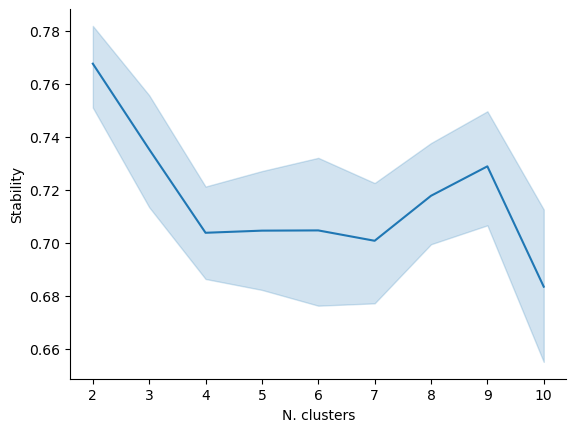

In [9]:
cc.pl.autok_stability(autok)

In [10]:
# Save all k solutions
for k in range(2, 11):
    comb.obs[f"cluster_cellcharter_k{k}"] = autok.predict(
        comb,
        use_rep="X_cellcharter",
        k=k,
    )

# Save automatically selected best solution
comb.obs["cluster_cellcharter"] = autok.predict(
    comb,
    use_rep="X_cellcharter",
)

2026-08-23 23:24:37 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:24:37 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:24:37 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-23 23:24:37 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-08-23 23:24:37 | [INFO] SLURM auto-requeueing enabled. Setting signal handlers.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
2026-08-23 23:24:38 | [INFO] GPU available: True (cuda), used: True
2026-08-23 23:24:38 | [INFO] TPU available: False, using: 0 TPU cores
2026-08-23 23:24:38 | [INFO] 💡 Tip: For seamless cloud logging and experimen

In [11]:
out_path = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-cellcharter.h5ad'
comb.write_h5ad(out_path)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


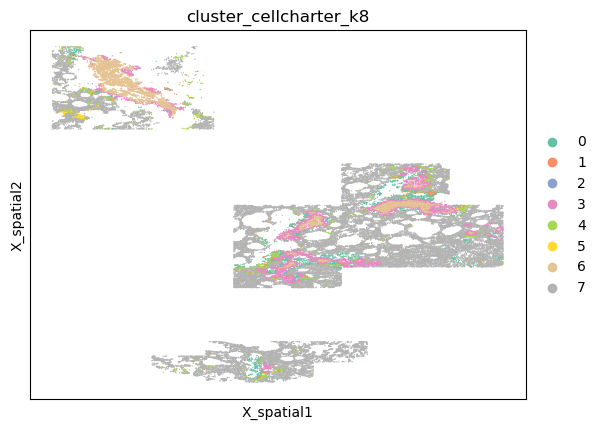

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


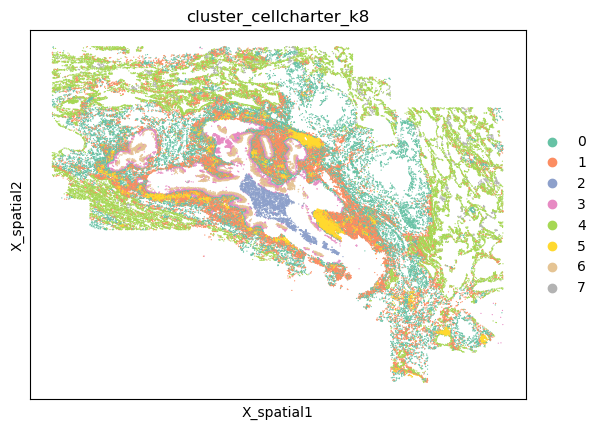

In [63]:
sample_ctrl = 'CTRL02'
sample_cf = 'PWCF06'
sc.pl.embedding(
    comb[comb.obs['sample_name']==sample_ctrl], 
    color=['cluster_cellcharter_k8'], 
    size=3,
    basis='X_spatial',
    palette='Set2',
)

sc.pl.embedding(
    comb[comb.obs['sample_name']==sample_cf], 
    color=['cluster_cellcharter_k8'], 
    size=3,
    basis='X_spatial',
    palette='Set2',
)

In [60]:
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

OLD_ANN_KEY = 'ann_lvl_3_refined'
NEW_ANN_KEY = 'cluster_cellcharter_k8'


# Keep only cells with both values
comparison = comb.obs[[OLD_ANN_KEY, NEW_ANN_KEY]].dropna().copy()

comparison[OLD_ANN_KEY] = comparison[OLD_ANN_KEY].astype(str)
comparison[NEW_ANN_KEY] = comparison[NEW_ANN_KEY].astype(str)

# -------------------------------------------------
# 1. Composition of every Leiden cluster
# -------------------------------------------------
counts = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
)

display(counts)

# Percentage composition within each Leiden cluster
percent_within_ann = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
    normalize="index",
) * 100

display(percent_within_ann.round(1))

cluster_cellcharter_k8,0,1,2,3,4,5,6,7
ann_lvl_3_refined,,,,,,,,
AT1,444,99,183,971,11529,46,4,9614
AT2,519,412,448,3872,69270,144,207,14917
AlvMac,397,48,353,666,4820,147,2,11859
Amb,5302,823,44377,6142,1665,688,474,19357
B,1453,9237,191,484,654,25232,3,460
BC,2507,604,712,48747,2176,676,5107,2311
CD4_T,2622,2723,289,763,869,5830,2,719
CD8_T,3103,3118,328,814,3108,4207,1,2107
Club,165,80,100,14055,225,32,21761,473


cluster_cellcharter_k8,0,1,2,3,4,5,6,7
ann_lvl_3_refined,,,,,,,,
AT1,1.9,0.4,0.8,4.2,50.4,0.2,0.0,42.0
AT2,0.6,0.5,0.5,4.3,77.1,0.2,0.2,16.6
AlvMac,2.2,0.3,1.9,3.6,26.4,0.8,0.0,64.8
Amb,6.7,1.0,56.3,7.8,2.1,0.9,0.6,24.6
B,3.9,24.5,0.5,1.3,1.7,66.9,0.0,1.2
BC,4.0,1.0,1.1,77.6,3.5,1.1,8.1,3.7
CD4_T,19.0,19.7,2.1,5.5,6.3,42.2,0.0,5.2
CD8_T,18.5,18.6,2.0,4.8,18.5,25.1,0.0,12.6
Club,0.4,0.2,0.3,38.1,0.6,0.1,59.0,1.3


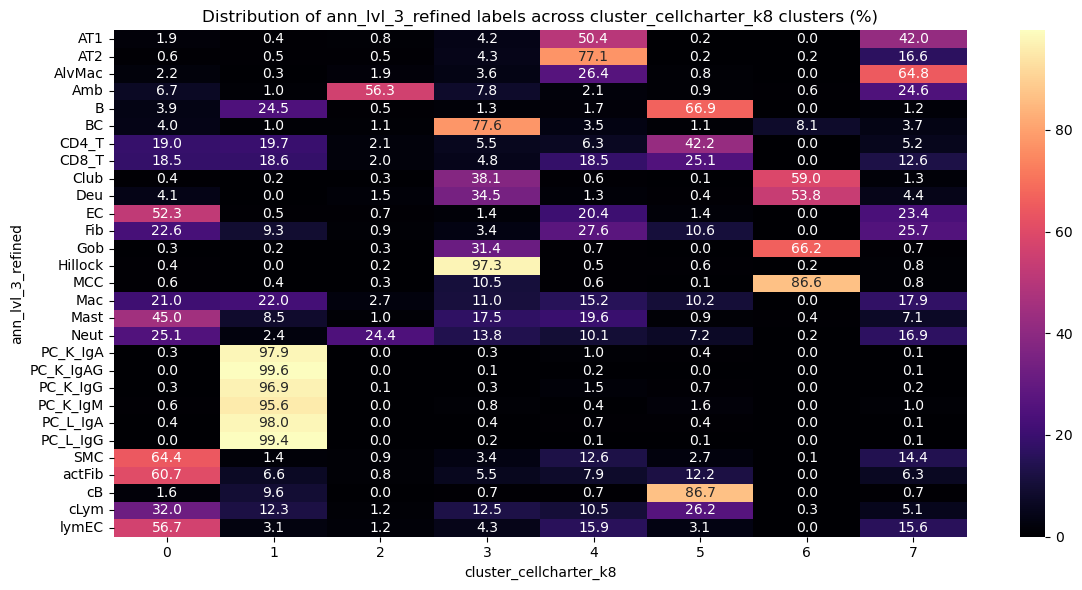

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(percent_within_ann, cmap="magma", annot=True, fmt=".1f")
plt.xlabel(NEW_ANN_KEY)
plt.ylabel(OLD_ANN_KEY)
plt.title(f"Distribution of {OLD_ANN_KEY} labels across {NEW_ANN_KEY} clusters (%)")
plt.tight_layout()
plt.show()

In [68]:
# name the niches 

niche_map_k8 = {
    "0": "Stromal_Interstitium",
    "1": "Plasma_Rich",
    "2": "Neutrophil_Rich",
    "3": "Basal_Airway",
    "4": "Alveolar_Epithelium",
    "5": "BALT",
    "6": "Luminal_Airway",
    "7": "Alveolar_Interstitium",
}

# level
niche_level_name = 'cluster_cellcharter_k8'

# save manual kmeans niches on 'kmeans_niche' column
comb.obs['kmeans_niches'] = comb.obs['niche_name']

# %% Map the niches to the new labels
comb.obs['cellcharter_niches'] = comb.obs[niche_level_name].map(niche_map_k8)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


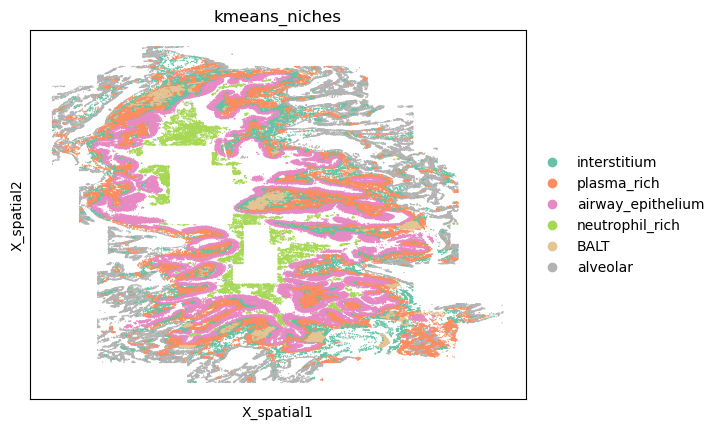

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


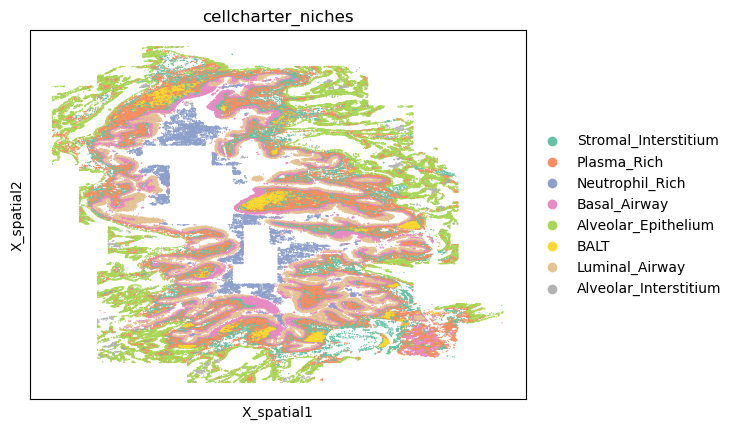

In [69]:
sample = 'PWCF05'

sc.pl.embedding(
    comb[comb.obs['sample_name']==sample], 
    color=['kmeans_niches'], 
    size=3,
    basis='X_spatial',
    palette='Set2',
)

sc.pl.embedding(
    comb[comb.obs['sample_name']==sample], 
    color=['cellcharter_niches'], 
    size=3,
    basis='X_spatial',
    palette='Set2',
)

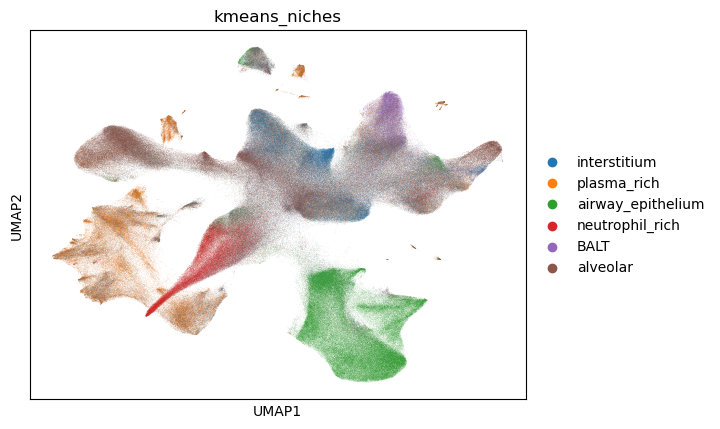

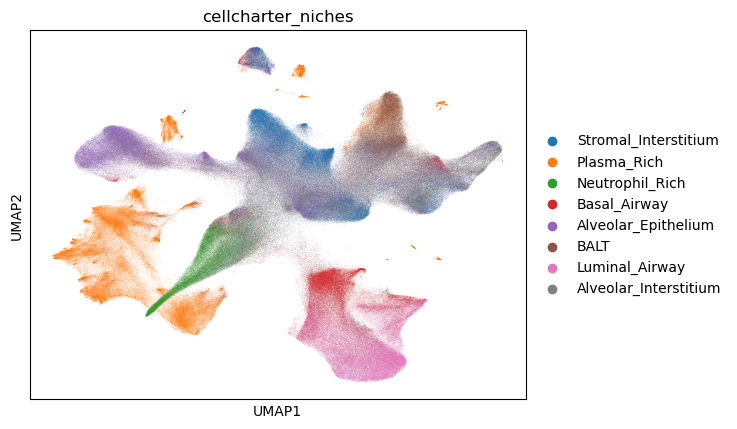

In [71]:
# print in umap so that the colours are saved onto adata.uns
sc.pl.umap(
    comb,
    color='kmeans_niches'
)

sc.pl.umap(
    comb, 
    color='cellcharter_niches'
)


In [72]:
ANN_VAR = "cellcharter_niches"

# %% colors

categories = comb.obs[ANN_VAR].cat.categories
colors = comb.uns[f"{ANN_VAR}_colors"]

print(colors)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']


In [73]:
out_path = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-cellcharter.h5ad'
comb.write_h5ad(out_path)